In [3]:
# Importing all the necessary libraries
import sys
!{sys.executable} -m pip install datasets
!{sys.executable} -m pip install torch torchvision



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
#importing the dataset from hugging face
from datasets import load_dataset

ds = load_dataset("ylecun/mnist")

#printout to make sure that it's loaded and happy
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})


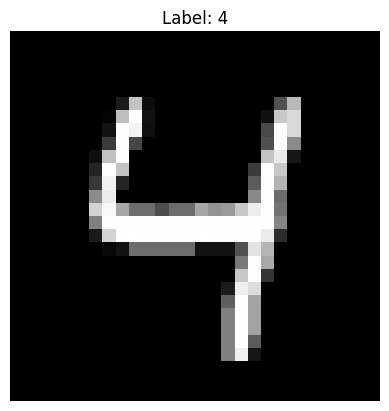

In [5]:
import random
import matplotlib.pyplot as plt

#Printing random sample from the dataset to see if it works
sample = ds["train"][random.randrange(len(ds["train"]))]

plt.imshow(sample["image"], cmap="gray")
plt.title(f"Label: {sample['label']}")
plt.axis("off")
plt.show()

In [6]:
#Converting data into a correct format, batch it and feed it to model 
import torch
from torchvision import transforms
from torch.utils.data import DataLoader

#using the transform to convert the image to a tensor and normalize it
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

#defining the dataset class, wrapping in PyTorch format
class MNISTDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform 

    def __len__(self):
        return len(self.hf_dataset)

#extracting the image and label from the dataset
    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item["image"]
        label = item["label"]

#Applying tensor conversion and normalization if needed
        if self.transform:
            image = self.transform(image)

        return image, label

#defining the train and test datasets
train_dataset = MNISTDataset(ds["train"], transform=transform)
test_dataset = MNISTDataset(ds["test"], transform=transform)

#Creating data loaders that will group data in batches and feed it to model
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [7]:
#defining the device to use for training (my computer doesn't have CUDA but doesn't hurt to see if the program will identify it correctly)
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [8]:
#Create neural network class: MLP (Multi-Layer Perceptron)
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            #flattening the image to a 1D vector because MNIST images are 1xcolor and 28x28px, MLP cannot process anything but 1D data
            nn.Flatten(),
            nn.Linear(28*28, 128),
            #Adding a ReLU function to introduce non-linearity
            nn.ReLU(),
            #adding a linear layer to output the 10 classes
            nn.Linear(128, 10)
        )

#def how data flows through the model
    def forward(self, x):
        return self.model(x)

In [9]:
#need optimization algorithms
import torch.optim as optim

#Defining training loop, which takes model, loader and number of epochs, pushing to cpu
def train(model, loader, epochs=3):
    model.to(device)

#Defining the optimizer and loss function using learning rate of 0.001 for Adam optimizer
    optimizer = optim.Adam(model.parameters(), lr=0.001)

#using CrossEntropyLoss as a loss function to compare model outputs vs correct labels and give penalty of model's wrong
    loss_fn = nn.CrossEntropyLoss()

#time to train my model!
    #3 epochs mean that the model will see the whole dataset 3 times
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()              # reset gradients
            outputs = model(images)            # forward pass
            loss = loss_fn(outputs, labels)    # compute loss
            loss.backward()                    # backpropagation
            optimizer.step()                   # update weights

            total_loss += loss.item()

        #print the loss of the epoch (should decrease over time)
        print(f"Epoch {epoch+1}: Loss = {total_loss/len(loader):.4f}")

In [10]:
#Definign function to evaluate accuracy of the model
def test(model, loader):
    model.eval()
    correct = 0
    total = 0

    #prevent the model from updating weights to use less memory
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(dim=1)

            #count how many predictions are correct
            correct += (preds == y).sum().item()
            #ount how many samples were processed
            total += y.size(0)

    mlp_acc = 100 * correct / total
    print(f"Test Accuracy: {mlp_acc:.2f}%")
    return mlp_acc

In [11]:
#Run Multi-Layer Perceptron model with random weights
mlp = MLP()

#Train model using the training data se
train(mlp, train_loader, epochs=3)

#Evaluate model using the test data set
mlp_acc = test(mlp, test_loader)

Epoch 1: Loss = 0.2557
Epoch 2: Loss = 0.1097
Epoch 3: Loss = 0.0762
Test Accuracy: 97.39%


In [12]:
#Defining Convolutional Neural Network model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        #Defining the convolutional layers
        self.conv_layers = nn.Sequential(
            #First layer: Detecting edges and curves in the image
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            #Max pooling to reduce the size of the image
            nn.MaxPool2d(2),

            #Second layer learning more advanced patterns
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        #Shape is now [32, 7, 7]
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    #Define how data flows through the model
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.classifier(x)
        return x

In [13]:
#Run Convolutional Neural Network model 
cnn = CNN()

#Train model using the training data set
train(cnn, train_loader, epochs=3)

#Evaluate model using the test data set
cnn_acc = test(cnn, test_loader)

Epoch 1: Loss = 0.1951
Epoch 2: Loss = 0.0563
Epoch 3: Loss = 0.0413
Test Accuracy: 98.60%


In [14]:
#Creating augmented training data for CNN model to improve its performance
from torchvision import transforms
from torch.utils.data import DataLoader

#This keeps the same 60,000 training images, but randomly changes them during training
augmented_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

#make sure only training data is augmented, do not  include test
train_dataset_augmented = MNISTDataset(
    ds["train"],
    transform=augmented_transform
)

#Train it on augmented data
train_loader_augmented = DataLoader(
    train_dataset_augmented,
    batch_size=64,
    shuffle=True
)

In [15]:
#Train CNN with augmentation
cnn_aug = CNN()

#Loss should be higher for augmented CNN than non-augmented, because the rotated images are harder 
train(cnn_aug, train_loader_augmented, epochs=3)

#test accuracy
cnn_aug_acc = test(cnn_aug, test_loader)

Epoch 1: Loss = 0.3261
Epoch 2: Loss = 0.1172
Epoch 3: Loss = 0.0895
Test Accuracy: 98.57%


In [16]:
#comapare accuracy between augmented and non-augmented training
print("=== Model Performance Comparison ===\n")

print(f"CNN (no augmentation):   {cnn_acc:.2f}%")
print(f"CNN (with augmentation): {cnn_aug_acc:.2f}%")

diff = cnn_aug_acc - cnn_acc

print("\nImprovement from augmentation:")
print(f"{diff:.2f}%")

if diff > 0:
    print("→ Augmentation improved performance")
elif diff < 0:
    print("→ Augmentation slightly hurt performance")
else:
    print("→ No change in performance")

=== Model Performance Comparison ===

CNN (no augmentation):   98.60%
CNN (with augmentation): 98.57%

Improvement from augmentation:
-0.03%
→ Augmentation slightly hurt performance


In [17]:
#Transformer processing 
class MNISTTransformer(nn.Module):
    #divide images into 7x7 chunks, define vector representing chunks, number of attention heads and transformer depth
    def __init__(self, patch_size=7, embed_dim=64, num_heads=4, num_layers=2):
        super().__init__()

        self.patch_size = patch_size
        self.num_patches = (28 // patch_size) ** 2         #create 16 patches for each image
        self.patch_dim = patch_size * patch_size         #49 values per patch

        #Converting each patch from 49 to 64 bc transformer needs fixed-size vectors
        self.patch_embed = nn.Linear(self.patch_dim, embed_dim)

        #define attention block with a vector size, multi-head attention and input shape
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            batch_first=True
        )

        #Stack transofrmer layers
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        #def output
        self.classifier = nn.Linear(embed_dim, 10)

    #Definition of data flow
    def forward(self, x):
        batch_size = x.size(0)

        #Splitting into patches (cut image into small squares)
        patches = x.unfold(2, self.patch_size, self.patch_size)
        patches = patches.unfold(3, self.patch_size, self.patch_size)

        #Create a sequence with a shape defined as [batch, 16 patches, 49 values]
        patches = patches.contiguous().view(
            batch_size,
            -1,
            self.patch_size * self.patch_size
        )

        #Make each patch into a vector
        x = self.patch_embed(patches)

        #Each patch attends to all the other patches and learns the relationships
        x = self.transformer(x)

        x = x.mean(dim=1)   #combine patches into one vector

        return self.classifier(x)   #classify

In [18]:
#train 
transformer = MNISTTransformer()

train(transformer, train_loader, epochs=3)

#test
transformer_acc = test(transformer, test_loader)

Epoch 1: Loss = 0.7293
Epoch 2: Loss = 0.3417
Epoch 3: Loss = 0.2641
Test Accuracy: 92.91%


In [19]:
#compare all the models' accuracy
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "MLP",
        "CNN",
        "CNN + Augmentation",
        "Transformer"
    ],
    "Test Accuracy (%)": [
        mlp_acc,
        cnn_acc,
        cnn_aug_acc,
        transformer_acc
    ]
})

print(results)

                Model  Test Accuracy (%)
0                 MLP              97.39
1                 CNN              98.60
2  CNN + Augmentation              98.57
3         Transformer              92.91


In [21]:
#automatically select the best-performing trained model

model_candidates = {
    "MLP": (mlp, mlp_acc),
    "CNN": (cnn, cnn_acc),
    "CNN + Augmentation": (cnn_aug, cnn_aug_acc),
    "Transformer": (transformer, transformer_acc)
}

best_model_name, (model, best_acc) = max(
    model_candidates.items(),
    key=lambda item: item[1][1]
)

model = model.to(device)
model.eval()

print(f"Selected best model: {best_model_name}")
print(f"Recognition rate before attacks: {best_acc:.2f}%")

Selected best model: CNN
Recognition rate before attacks: 98.60%


In [ ]:
def recognition_rate(model, loader):
    model.eval()
    correct = 0
    total = 0

    #calc the model performance before attacks
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    print(f"Recognition rate before attacks: {acc:.2f}%")
    return acc

clean_acc = recognition_rate(model, test_loader) #check how well the model performs before attacks

Recognition rate before attacks: 98.60%


In [ ]:
#Define valid pixel range after normalization to avoid unrealistic pixel values
mean = 0.1307 #reusing from normalized images above
std = 0.3081

min_pixel = (0 - mean) / std
max_pixel = (1 - mean) / std

print("Minimum normalized pixel value:", min_pixel)
print("Maximum normalized pixel value:", max_pixel)

Minimum normalized pixel value: -0.424212917883804
Maximum normalized pixel value: 2.82148653034729


In [24]:
#Fast Gradient Sign Method - one step AA - slightly changes the input image so the model makes wrong prediction based on that altered input
def fgsm_attack(model, images, labels, epsilon): #epislon: attack strength
    images = images.clone().detach().to(device) #copy images
    labels = labels.to(device) #move to cpu/gpu, wish I had CUDA but in this economy...

    images.requires_grad = True #enable gradients on images

    outputs = model(images) #predict
    loss = nn.CrossEntropyLoss()(outputs, labels) #calc loss

    model.zero_grad() #clear gradient
    loss.backward() #calc gradients to see how changing each pixel affects loss

    adv_images = images + epsilon * images.grad.sign() #creating adversarial imgs with small perturbations
    adv_images = torch.clamp(adv_images, min_pixel, max_pixel) #clamping to prevent invalid pixel values

    return adv_images.detach() 

In [26]:
#PGD/I-FGSM
def pgd_attack(model, images, labels, epsilon, alpha=0.01, steps=10): #epsilon = max total attack size, alpha = step size for each iteraiton, steps = # of iterations
    original_images = images.clone().detach().to(device)
    labels = labels.to(device)

    adv_images = original_images.clone().detach()

    #loop - every iteration modifies the image slightly. Since step = 10, the image will be modified 10 times
    for _ in range(steps): 
        adv_images.requires_grad = True

        outputs = model(adv_images)
        loss = nn.CrossEntropyLoss()(outputs, labels) #compute how wrong the model is

        model.zero_grad()
        loss.backward()

        adv_images = adv_images + alpha * adv_images.grad.sign() #similar to FGSM but using alpha instead of epsilon

        #limit total perturbation & calculate how much the adversarial image differs from the original
        perturbation = torch.clamp(
            adv_images - original_images,
            -epsilon,
            epsilon
        )

        adv_images = original_images + perturbation
        adv_images = torch.clamp(adv_images, min_pixel, max_pixel)
        adv_images = adv_images.detach()

    return adv_images

In [28]:
#Momentum I-FGSM attack - similar to PGD/I-FGSM, but adds momentum
def momentum_ifgsm_attack(model, images, labels, epsilon, alpha=0.01, steps=10, decay=1.0): #decay controls how much previous momentum is preserved
    original_images = images.clone().detach().to(device)
    labels = labels.to(device)

    adv_images = original_images.clone().detach()
    momentum = torch.zeros_like(adv_images).to(device) #add momentum - accumulate gradient direction

    for _ in range(steps):
        adv_images.requires_grad = True

        outputs = model(adv_images)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        model.zero_grad()
        loss.backward()

        grad = adv_images.grad

        grad = grad / torch.mean(torch.abs(grad), dim=(1, 2, 3), keepdim=True)
        momentum = decay * momentum + grad

        adv_images = adv_images + alpha * momentum.sign()

        perturbation = torch.clamp(
            adv_images - original_images,
            -epsilon,
            epsilon
        )

        adv_images = original_images + perturbation
        adv_images = torch.clamp(adv_images, min_pixel, max_pixel)
        adv_images = adv_images.detach()

    return adv_images

In [31]:
#Evaluate my attacks
def evaluate_attack(model, loader, attack_fn, epsilon, **attack_kwargs): #loader = test data, attack_fn = which attack is used, attack_kwargs = extra settings like alpha, steps...
    model.eval()

    #set counters to 0
    originally_correct = 0
    fooled = 0

    #loop processing every test set batch by batch
    for images, labels in loader: 
        images, labels = images.to(device), labels.to(device)

        #predictions based on roiginal images
        clean_outputs = model(images)
        clean_preds = clean_outputs.argmax(dim=1)

        correct_mask = clean_preds == labels #define which are true examples

        if correct_mask.sum() == 0: #skip if none are true
            continue

        #generate fake images based on attack function
        adv_images = attack_fn(
            model,
            images,
            labels,
            epsilon,
            **attack_kwargs
        )

        #predict adversial imgs
        adv_outputs = model(adv_images)
        adv_preds = adv_outputs.argmax(dim=1)

        #update the counters
        originally_correct += correct_mask.sum().item()
        fooled += ((adv_preds != labels) & correct_mask).sum().item()

    asr = 100 * fooled / originally_correct

    print(f"Attack Success Rate: {asr:.2f}%")
    return asr

In [36]:
#TIME TO ATTACK!!!!!!!!!!!!!!!!!

epsilon = 0.2

fgsm_asr = evaluate_attack(
    model,
    test_loader,
    fgsm_attack,
    epsilon=epsilon
)

pgd_asr = evaluate_attack(
    model,
    test_loader,
    pgd_attack,
    epsilon=epsilon,
    alpha=0.01,
    steps=20
)

momentum_asr = evaluate_attack(
    model,
    test_loader,
    momentum_ifgsm_attack,
    epsilon=epsilon,
    alpha=0.01,
    steps=20,
    decay=1.0
)

Attack Success Rate: 6.88%
Attack Success Rate: 10.27%
Attack Success Rate: 9.98%


In [38]:
#Results
attack_results = pd.DataFrame({
    "Method": [
        "No Attack",
        "FGSM",
        "I-FGSM / PGD",
        "Momentum I-FGSM"
    ],
    "Epsilon": [
        0,
        epsilon,
        epsilon,
        epsilon
    ],
    "Metric": [
        "Recognition Rate",
        "Attack Success Rate",
        "Attack Success Rate",
        "Attack Success Rate"
    ],
    "Result (%)": [
        clean_acc,
        fgsm_asr,
        pgd_asr,
        momentum_asr
    ]
})

print(attack_results)

attack_results.to_csv("attack_results.csv", index=False)

print("Saved results to attack_results.csv")

            Method  Epsilon               Metric  Result (%)
0        No Attack      0.0     Recognition Rate   98.600000
1             FGSM      0.2  Attack Success Rate    6.876268
2     I-FGSM / PGD      0.2  Attack Success Rate   10.273834
3  Momentum I-FGSM      0.2  Attack Success Rate    9.979716
Saved results to attack_results.csv
